# 컨볼루션 신경망
※ 해당 실습은 CNN을 활용한 이진분류 예제입니다.


## Dogs vs cats

- 이미지 데이터 경로 설정

In [30]:
# train 데이터 폴더 정의
train_cats_dir = './cats_and_dogs_filtered/train/cats/'
train_dogs_dir = './cats_and_dogs_filtered/train/dogs/'

# validation 데이터 폴더 정의
val_cats_dir = './cats_and_dogs_filtered/validation/cats/'
val_dogs_dir = './cats_and_dogs_filtered/validation/dogs/'

- train/validation 데이터 파일 정의

In [31]:
import os

train_cats_fnames = os.listdir(train_cats_dir)
train_dogs_fnames = os.listdir(train_dogs_dir) 

print(train_cats_fnames[:5])
print(train_dogs_fnames[:5])

['cat.165.jpg', 'cat.314.jpg', 'cat.997.jpg', 'cat.932.jpg', 'cat.749.jpg']
['dog.6.jpg', 'dog.989.jpg', 'dog.202.jpg', 'dog.779.jpg', 'dog.819.jpg']


In [32]:
val_cats_fnames = os.listdir(val_cats_dir)
val_dogs_fnames = os.listdir(val_dogs_dir)

print(val_cats_fnames[:5])
print(val_dogs_fnames[:5])

['cat.2285.jpg', 'cat.2458.jpg', 'cat.2059.jpg', 'cat.2256.jpg', 'cat.2339.jpg']
['dog.2450.jpg', 'dog.2493.jpg', 'dog.2486.jpg', 'dog.2093.jpg', 'dog.2244.jpg']


- 학습데이터와 검증데이터 건수 확인

In [33]:
print(f'학습데이터 - cat: {len(train_cats_fnames)}, dog: {len(train_dogs_fnames)}')
print(f'검증데이터 - cat: {len(val_cats_fnames)}, dog: {len(val_dogs_fnames)}')

학습데이터 - cat: 1000, dog: 1000
검증데이터 - cat: 500, dog: 500


- 데이터 시각화

['./cats_and_dogs_filtered/train/cats/cat.79.jpg', './cats_and_dogs_filtered/train/cats/cat.697.jpg', './cats_and_dogs_filtered/train/cats/cat.844.jpg', './cats_and_dogs_filtered/train/cats/cat.105.jpg', './cats_and_dogs_filtered/train/cats/cat.277.jpg', './cats_and_dogs_filtered/train/cats/cat.751.jpg', './cats_and_dogs_filtered/train/cats/cat.329.jpg', './cats_and_dogs_filtered/train/cats/cat.304.jpg']
['./cats_and_dogs_filtered/train/dogs/dog.512.jpg', './cats_and_dogs_filtered/train/dogs/dog.941.jpg', './cats_and_dogs_filtered/train/dogs/dog.628.jpg', './cats_and_dogs_filtered/train/dogs/dog.522.jpg', './cats_and_dogs_filtered/train/dogs/dog.267.jpg', './cats_and_dogs_filtered/train/dogs/dog.927.jpg', './cats_and_dogs_filtered/train/dogs/dog.475.jpg', './cats_and_dogs_filtered/train/dogs/dog.220.jpg']


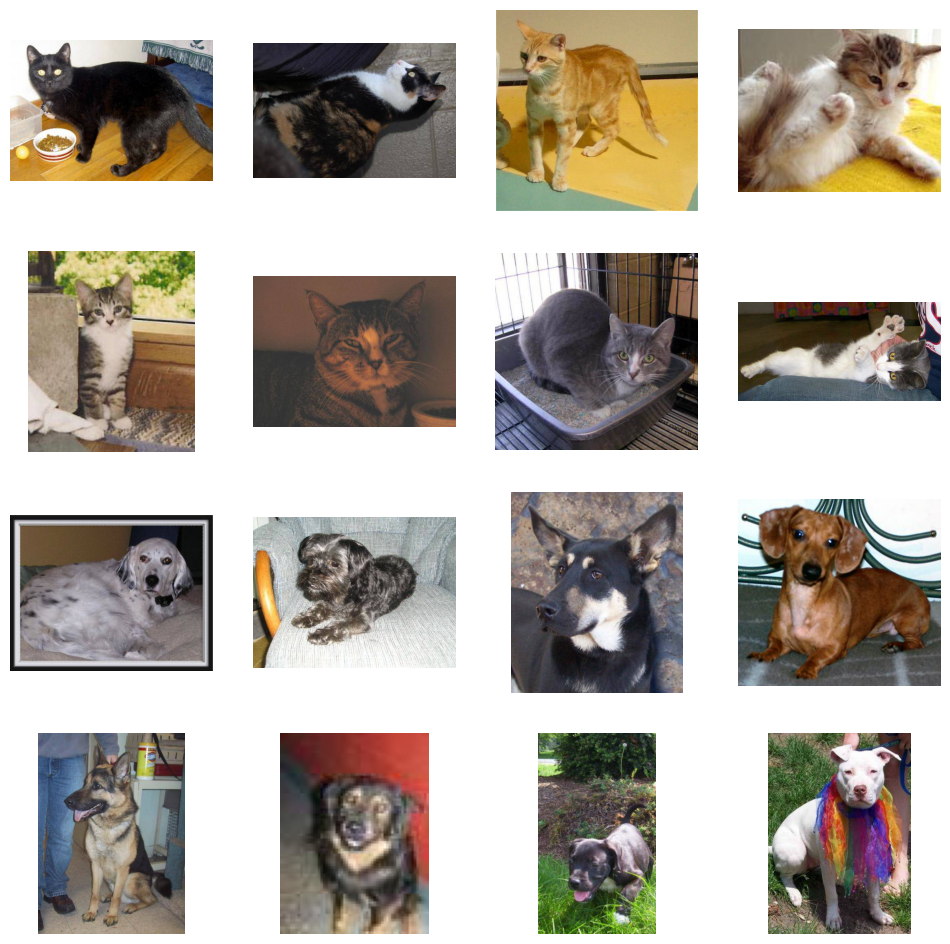

In [37]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

nrows, ncols = 4, 4  # 출력 행/열 개수 정의
pic_index = 0

fig = plt.gcf()
fig.set_size_inches(ncols*3, nrows*3)

pic_index += 108 

next_cats_pix = [ os.path.join(train_cats_dir, fname)  
                 for fname in train_cats_fnames[pic_index-8:pic_index]]

next_dogs_pix = [ os.path.join(train_dogs_dir, fname)  
                 for fname in train_dogs_fnames[pic_index-8:pic_index]]

print(next_cats_pix)
print(next_dogs_pix)

for i, img_path in enumerate(next_cats_pix + next_dogs_pix):
    axs = plt.subplot(nrows, ncols, i+1)   # 4행/4열의 이미지 출력
    axs.axis('off')   # 눈금선 제거

    img = mpimg.imread(img_path)
    plt.imshow(img)

plt.show()

- 데이터 스케일링

In [38]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 이미지 픽셀을 0 ~ 1 사이의 값으로 스케일 조정
img_datagen = ImageDataGenerator(rescale=1./255)

# 이미지 제너레이터 적용
train_generator = img_datagen.flow_from_directory(
    './cats_and_dogs_filtered/train/',   # 학습 이미지 저장 폴더
    batch_size=20,                       # 모델에 전달한 이미지 개수(배치크기)
    target_size=(150, 150),              # 이미지 사이즈(리사이즈)
    class_mode='binary'                  # 이진 분류(cat vs dos, 0 또는 1)
    )

validation_generator = img_datagen.flow_from_directory(
    './cats_and_dogs_filtered/validation/',   # 학습 이미지 저장 폴더
    batch_size=20,                       # 모델에 전달한 이미지 개수(배치크기)
    target_size=(150, 150),              # 이미지 사이즈(리사이즈)
    class_mode='binary'                  # 이진 분류(cat vs dos, 0 또는 1)
    )

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


### 모델 구성
- Conv2D, MaxPool2D

In [39]:
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dropout, Dense, Flatten
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.models import Sequential

In [50]:
model = Sequential()
model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu', input_shape=(150, 150, 3)))
model.add(MaxPool2D((2, 2), padding='same'))
model.add(Dropout(0.2))

model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(MaxPool2D((2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(MaxPool2D((2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(MaxPool2D((2, 2)))
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/root/miniconda3/envs/dl_edu/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [51]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,654,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,895,553 (11.05 MB)

 Trainable params: 2,895,553 (11.05 MB)

 Non-trainable params: 0 (0.00 B)

- 컴파일 및 모델 학습하기

In [52]:
# binary_crossentropy: 이진분류
model.compile(loss='binary_crossentropy',
              optimizer=RMSprop(0.0001),
              metrics=['acc'])

In [53]:
# 스템값 계산
def get_step(train_len, batch_size):
    if(train_len % batch_size > 0):
        return train_len // batch_size + 1
    else:
        return train_len // batch_size

In [54]:
history = model.fit(train_generator,                     # 학습 데이터
                    steps_per_epoch=get_step(2000, 32),  # 한 epoch당 베치 반복 횟수
                    epochs=100,                           # 전체 학습 반복 횟수
                    validation_data=validation_generator,# 검증 데이터 
                    validation_steps=50)                 # 검증 데이터 반복 횟수

Epoch 1/100


I0000 00:00:1773814307.324347   90921 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_59039__.48


63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - acc: 0.4865 - loss: 0.7141 - val_acc: 0.4990 - val_loss: 0.6931
Epoch 2/100
36/63 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - acc: 0.4738 - loss: 0.7013

/root/miniconda3/envs/dl_edu/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - acc: 0.4905 - loss: 0.6961 - val_acc: 0.5000 - val_loss: 0.6921
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - acc: 0.5270 - loss: 0.6926 - val_acc: 0.5510 - val_loss: 0.6912
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - acc: 0.5189 - loss: 0.6900 - val_acc: 0.5170 - val_loss: 0.6916
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - acc: 0.5429 - loss: 0.6876 - val_acc: 0.5310 - val_loss: 0.6908
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - acc: 0.5608 - loss: 0.6875 - val_acc: 0.5590 - val_loss: 0.6891
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - acc: 0.5524 - loss: 0.6840 - val_acc: 0.5600 - val_loss: 0.6872
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - acc: 0.5676 - loss: 0.6838 - val_acc: 0.5730 - val_loss: 0.6849
Epoch 9/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - acc: 0.5889 - loss: 0.6746 - val_acc: 0.5140 - val_loss: 0.6899
Epoch 10/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - acc: 0.5919 -

- 학습 과정 그려보기

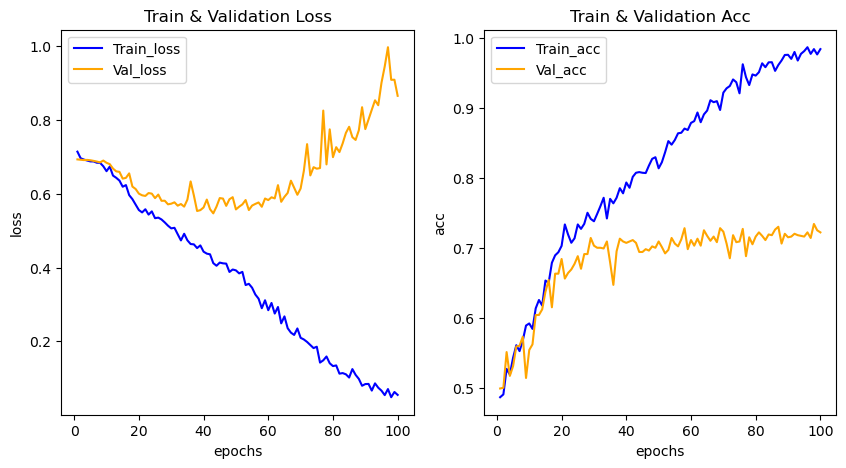

In [55]:
import matplotlib.pyplot as plt
his_data = history.history

loss = his_data['loss']
val_loss = his_data['val_loss']

epochs = range(1, len(loss)+1)

fig = plt.figure(figsize=(10, 5))

# 훈련 및 검증 손실율(lossl)
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(epochs, loss, color='blue', label='Train_loss')
ax1.plot(epochs, val_loss, color='orange', label='Val_loss')
ax1.set_title('Train & Validation Loss')
ax1.set_xlabel('epochs')
ax1.set_ylabel('loss')
ax1.legend()

# 훈련 및 검증 정확도
acc = his_data['acc']
val_acc = his_data['val_acc']

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(epochs, acc, color='blue', label='Train_acc')
ax2.plot(epochs, val_acc, color='orange', label='Val_acc')
ax2.set_title('Train & Validation Acc')
ax2.set_xlabel('epochs')
ax2.set_ylabel('acc')
ax2.legend()

plt.show()

- 학습한 모델 저장

In [56]:
# model.save('./models/cat_dog_model.h5') 
model.save('./models/cat_dog_model.keras') 

#### 모델 테스트

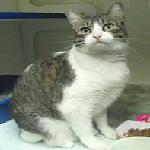

In [57]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img('./cats_and_dogs_filtered/validation/cats/cat.2024.jpg',
                     target_size=(150, 150))
img

In [63]:
img_arr = image.img_to_array(img)

print(img_arr)

[[[108. 116.  92.]
  [108. 116.  92.]
  [108. 116.  92.]
  ...
  [102. 106.  83.]
  [110. 114.  91.]
  [112. 116.  93.]]

 [[108. 116.  92.]
  [108. 116.  92.]
  [108. 116.  92.]
  ...
  [106. 110.  87.]
  [114. 118.  95.]
  [117. 121.  98.]]

 [[108. 116.  92.]
  [108. 116.  92.]
  [108. 116.  92.]
  ...
  [108. 112.  89.]
  [118. 122.  99.]
  [121. 125. 102.]]

 ...

 [[218. 240. 238.]
  [218. 240. 238.]
  [220. 242. 240.]
  ...
  [209. 225. 198.]
  [209. 225. 198.]
  [209. 225. 198.]]

 [[218. 240. 238.]
  [218. 240. 238.]
  [220. 242. 240.]
  ...
  [209. 225. 198.]
  [209. 225. 198.]
  [209. 225. 198.]]

 [[218. 240. 238.]
  [218. 240. 238.]
  [220. 242. 240.]
  ...
  [209. 225. 198.]
  [209. 225. 198.]
  [209. 225. 198.]]]


In [64]:
# 학습시 사용한 데이터 차원과 동일하게 변경(2000, 150, 150, 3)
# 3차원(150, 150, 3) => 4차원 변경((1. 150, 150, 3))
print(f'변경전:{img_arr.shape}')
img_arr_dims = np.expand_dims(img_arr, axis=0)
print(f'변경후:{img_arr_dims.shape}')

변경전:(150, 150, 3)
변경후:(1, 150, 150, 3)


In [75]:
pred = model.predict(img_arr_dims)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


array([[0.]], dtype=float32)

#### 서비스를 위한 함수 생성 및 Cat & Dog 분류

In [ ]:
from tensorflow.keras.preprocessing import image   # 이미지 처리
from tensorflow.keras.models import load_model     # 모델 읽어오기
import numpy as np
import matplotlib.pyplot as plt

In [72]:
model = load_model('./models/cat_dog_model.keras')

In [76]:
# 서비스 함수 생성
def pred(filename):
    # 이미지 읽어오기
    input_img = image.load_img(filename, target_size=(150, 150))
    plt.imshow(input_img)

    # 이미지 차원 변경
    img_arr = image.img_to_array(input_img)
    images = np.expand_dims(img_arr, axis=0)

    classification = model.predict(images)
    print(classification[0])

    if classification[0][0] > 0:
        print(filename.split('/')[-1] + '은 강아지 사진입니다.')
    else:
        print(filename.split('/')[-1] + '은 고양이 사진입니다.')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
[1.]
dog.14.jpg은 강아지 사진입니다.


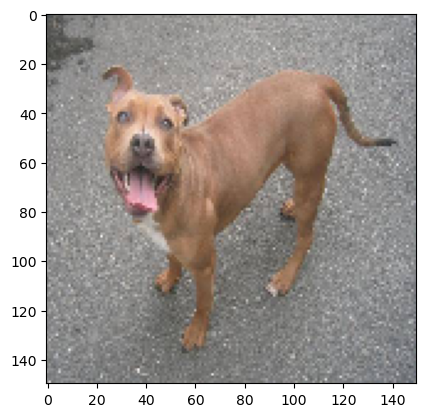

In [77]:
pred('./cats_and_dogs_filtered/train/dogs/dog.14.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
[0.]
cat1.jpg은 고양이 사진입니다.


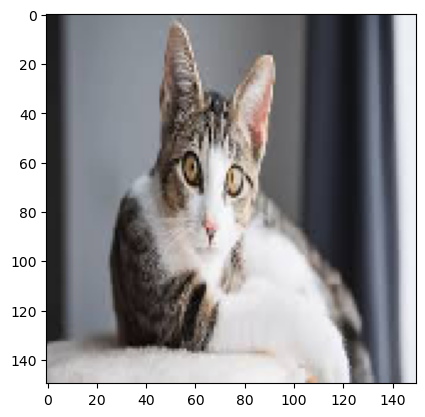

In [78]:
pred('./images/cat1.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
[1.]
capture_5.jpg은 강아지 사진입니다.


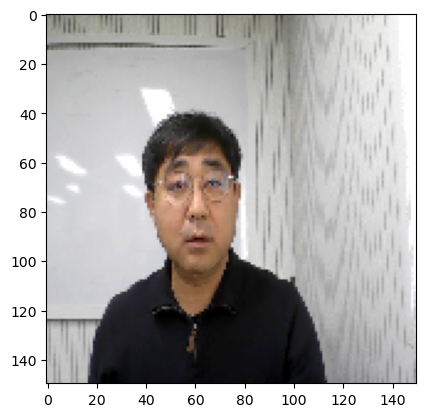

In [79]:
pred('./images/capture_5.jpg')